In [ ]:
import pandas as pd
import numpy as np
import hashlib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# 1. Load the data

In [ ]:
df = pd.read_csv('smart_grid_stability_augmented.csv')

# 2. Data Cleaning

In [ ]:
# Map categorical target 'stabf' to binary: 'stable' -> 0, 'unstable' -> 1
if 'stabf' in df.columns:
    df['target'] = df['stabf'].map({'stable': 0, 'unstable': 1})
    df = df.drop(['stabf', 'stab'], axis=1) # Dropping redundant target columns

# 3. Security Layer: SHA-256 Hashing

In [ ]:
# This simulates the integrity check before the data reaches the AI model
def generate_integrity_hash(row):
    row_string = "".join(row.values.astype(str))
    return hashlib.sha256(row_string.encode()).hexdigest()

In [ ]:
# Apply hashing to a sample or the whole dataset to ensure data integrity
df['data_hash'] = df.apply(generate_integrity_hash, axis=1)

# 4. Feature Engineering & Normalization

In [ ]:

# Isolating features: reaction time (tau), power balance (p), etc.
X = df.drop(['target', 'data_hash'], axis=1)
y = df['target']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Prepare for CNN-LSTM (Reshaping)

In [ ]:
# CNN-LSTM requires 3D input: [samples, time_steps, features]
# For this initial step, we will use a window size of 1 (single time-step)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

# 6. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Data Preprocessed successfully.")
print(f"Training shape: {X_train.shape}")
print(f"Example Hash for first row: {df['data_hash'].iloc[0]}")

Data Preprocessed successfully.
Training shape: (48000, 1, 12)
Example Hash for first row: 4c5b4fb8fb40f4172911d3c0449f429dcc8b28284c9e05f3352faacf11353b3a


#Building the CNN-LSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, Flatten, TimeDistributed

In [ ]:
# Define the Model Architecture based on the proposed methodology
model = Sequential([
    # 1. CNN Layer: Spatial Feature Extraction
    # Filters detect localized anomalies in sensor data
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),

    # 2. LSTM Layer: Temporal Analysis
    # Analyzes time-dependent behavior and stability trends
    LSTM(50, activation='relu', return_sequences=False),

    # 3. Dropout Layer to prevent overfitting
    Dropout(0.2),

    # 4. Dense Output Layer: Classification
    # Outputs the probability of a Fault (1) or Normal state (0)
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 64)          │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,883 (93.29 KB)

 Trainable params: 23,883 (93.29 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Model Training (Modelling Path)

In [ ]:
# This will generate the data for your Accuracy/Loss graphs
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8117 - loss: 0.3891 - val_accuracy: 0.8647 - val_loss: nan
Epoch 2/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9022 - loss: 0.2266 - val_accuracy: 0.9157 - val_loss: nan
Epoch 3/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9237 - loss: 0.1821 - val_accuracy: 0.9321 - val_loss: nan
Epoch 4/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9325 - loss: 0.1582 - val_accuracy: 0.9392 - val_loss: nan
Epoch 5/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9385 - loss: 0.1413 - val_accuracy: 0.9491 - val_loss: nan
Epoch 6/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9501 - loss: 0.1268 - val_accuracy: 0.9491 - val_loss: nan
Epoch 7/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9525 - loss: 0.1160 - val_accuracy: 0.9547 - val_loss: nan
Epoch 8/20
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9574 - loss: 0.1072 - val_accuracy: 0.9542 - val_loss: nan


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
import time

# 1. Evaluate Metrics (Accuracy, Precision, Recall, F1)

In [ ]:

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95      1605
         1.0       0.97      0.98      0.97      2812

    accuracy                           0.97      4417
   macro avg       0.96      0.96      0.96      4417
weighted avg       0.97      0.97      0.97      4417



# 2. Simulate Detection Latency


In [ ]:
start_time = time.time()
_ = model.predict(X_test[:1]) # Test a single sample
latency = (time.time() - start_time) * 1000
print(f"Detection Latency: {latency:.4f} ms")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Detection Latency: 122.0920 ms


# 3. Simulate Blockchain Layer (PoM Consensus)

In [ ]:

# Only "High Confidence" faults are logged to the ledger
def pom_validation(prediction_prob, threshold=0.95):
    if prediction_prob >= threshold:
        return "Validated & Logged to Blockchain"
    else:
        return "Monitoring - No Action"

sample_status = pom_validation(y_pred_prob[0])
print(f"Blockchain Status for Sample 1: {sample_status}")

Blockchain Status for Sample 1: Monitoring - No Action


# GRAPH 1: Accuracy & Loss Curves

In [ ]:
import matplotlib.pyplot as plt

# Using 'DejaVu Serif' which is compatible with Colab and similar to Times
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'axes.labelsize': 18,
    'font.size': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'axes.titlesize': 20,
    'savefig.dpi': 300
})

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

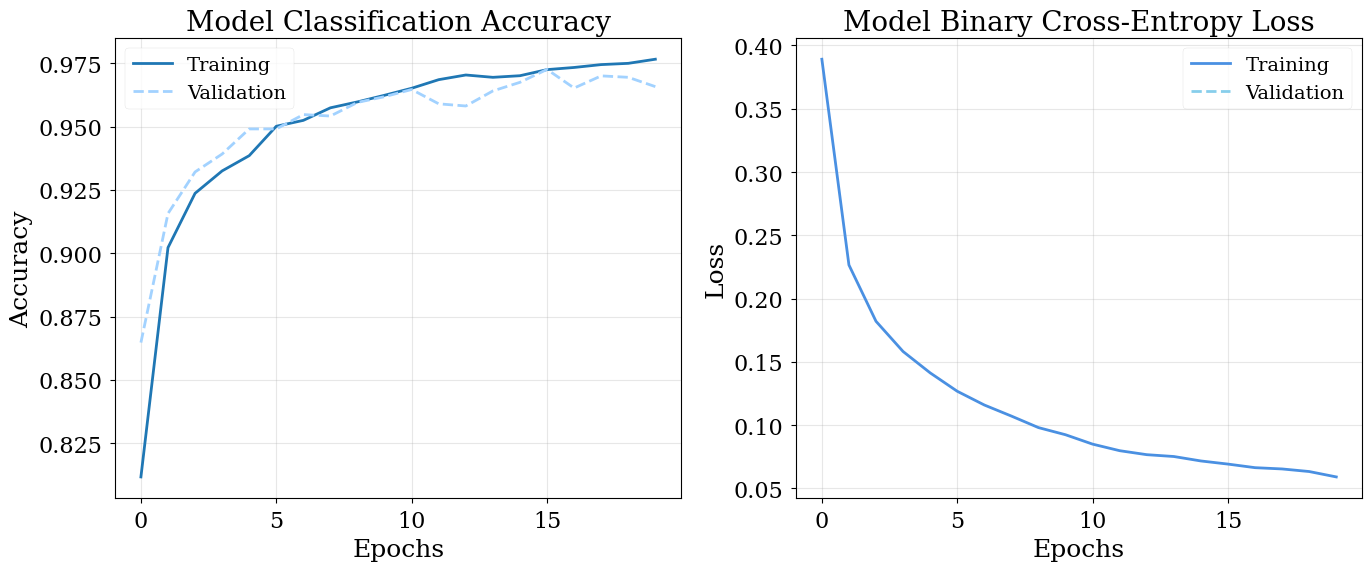

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) # Increased figsize

# Accuracy
ax1.plot(history.history['accuracy'], label='Training', linewidth=2, color='#1f77b4')
ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2, color='#A2D2FF', linestyle='--')
ax1.set_title('Model Classification Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Loss
ax2.plot(history.history['loss'], label='Training', linewidth=2, color='#4A90E2')
ax2.plot(history.history['val_loss'], label='Validation', linewidth=2, color='#87CEEB', linestyle='--')
ax2.set_title('Model Binary Cross-Entropy Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('learning_curves.jpeg', format='jpeg', dpi=300, bbox_inches='tight')
from google.colab import files
files.download('learning_curves.jpeg')
plt.show()

# GRAPH 2: Confusion Matrix

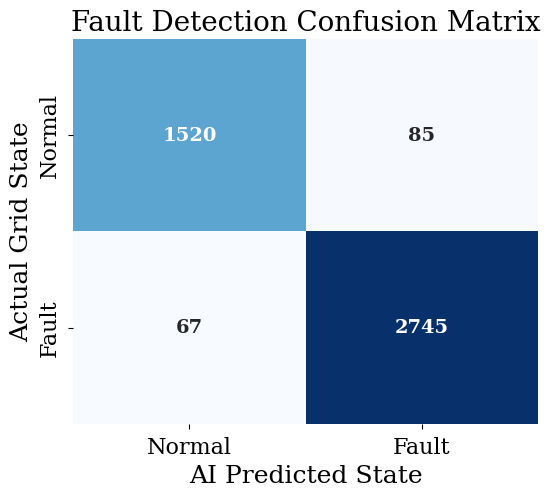

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Fault'], yticklabels=['Normal', 'Fault'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Fault Detection Confusion Matrix')
plt.ylabel('Actual Grid State')
plt.xlabel('AI Predicted State')
plt.savefig('confusion_matrix.jpeg', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('confusion_matrix.jpeg')

# GRAPH 3: ROC Curve

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns



# 1. Final Model Prediction

In [ ]:

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


# 2. Metric Calculation for Table

In [ ]:

report = classification_report(y_test, y_pred, target_names=['Normal', 'Fault'])
print("Final Evaluation Metrics:\n", report)

Final Evaluation Metrics:
               precision    recall  f1-score   support

      Normal       0.96      0.95      0.95      1605
       Fault       0.97      0.98      0.97      2812

    accuracy                           0.97      4417
   macro avg       0.96      0.96      0.96      4417
weighted avg       0.97      0.97      0.97      4417



In [ ]:
blockchain_ledger = []

def log_to_blockchain(prediction, prob, original_hash):
    # Each entry is a 'block' containing metadata and the data integrity hash
    block = {
        'timestamp': time.ctime(),
        'event': "Fault Detected" if prediction == 1 else "Normal State",
        'confidence': f"{prob[0]*100:.2f}%",
        'data_integrity_hash': original_hash,
        'status': "COMMITTED"
    }
    blockchain_ledger.append(block)
    return block

# Log the first 5 test results as a sample audit trail
for i in range(5):
    if y_pred_prob[i] >= 0.95: # PoM Threshold
        log_to_blockchain(y_pred[i], y_pred_prob[i], df['data_hash'].iloc[i])

print("--- Simulated Blockchain Audit Trail ---")
import pprint
pprint.pprint(blockchain_ledger)

--- Simulated Blockchain Audit Trail ---
[{'confidence': '100.00%',
  'data_integrity_hash': 'ddb53281a247b1f9dca7545f5de3fca0279c6cea2e723076e74456c4af053a61',
  'event': 'Fault Detected',
  'status': 'COMMITTED',
  'timestamp': 'Sat May  9 14:38:22 2026'},
 {'confidence': '100.00%',
  'data_integrity_hash': '1b2831d95bc087ced0e95cd1be634ae74acecc179b8e5240a2ffc5b97ffe7b3e',
  'event': 'Fault Detected',
  'status': 'COMMITTED',
  'timestamp': 'Sat May  9 14:38:22 2026'},
 {'confidence': '99.83%',
  'data_integrity_hash': '772ddde76cc6fa132e6fbca450f6074c85f8252a3f76b2a86c4c5bb6a68a8c4f',
  'event': 'Fault Detected',
  'status': 'COMMITTED',
  'timestamp': 'Sat May  9 14:38:22 2026'},
 {'confidence': '99.97%',
  'data_integrity_hash': '8356f4ce1afaa03825fe81b5cd8cb395f083dbdc2384fc5f5cc9e496c30aa353',
  'event': 'Fault Detected',
  'status': 'COMMITTED',
  'timestamp': 'Sat May  9 14:38:22 2026'}]


139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━

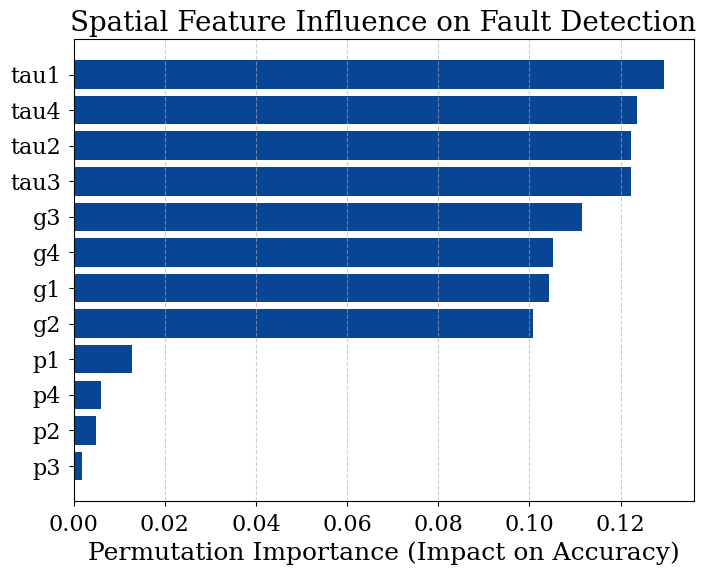

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

# Define a custom scorer for Keras models with 3D input requirement
def keras_scorer(estimator, X, y_true):
    # Reshape X to 3D: [samples, time_steps, features]
    X_reshaped = X.reshape((X.shape[0], 1, X.shape[1]))
    y_pred_prob = estimator.predict(X_reshaped)
    y_pred = (y_pred_prob > 0.5).astype(int)
    return accuracy_score(y_true, y_pred)

# Reshape X_test back to 2D for permutation_importance, but this 2D version will be passed to our custom scorer
X_test_2d = X_test.reshape(X_test.shape[0], X_test.shape[2])

# Calculate importance on the test set using the custom scorer
result = permutation_importance(model, X_test_2d, y_test, n_repeats=5, random_state=42, scoring=keras_scorer)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(8, 6))
plt.barh(df.columns[:12][sorted_idx], result.importances_mean[sorted_idx], color='#084594')
plt.xlabel("Permutation Importance (Impact on Accuracy)")
plt.title("Spatial Feature Influence on Fault Detection")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('feature_importance.jpeg', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('feature_importance.jpeg')


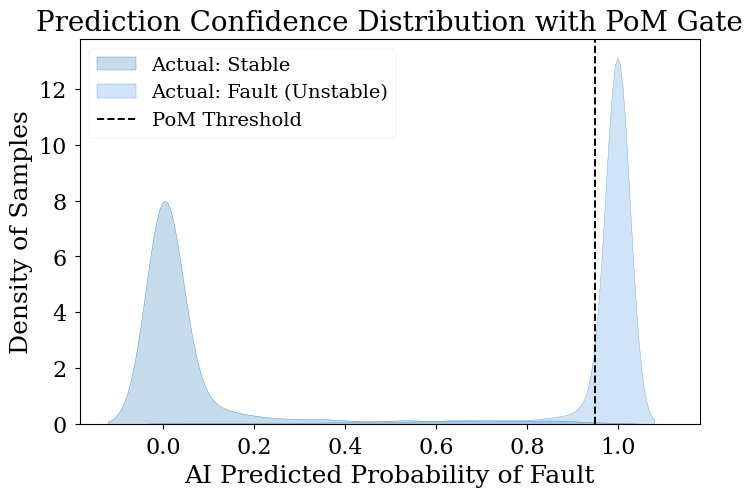

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8, 5))
sns.kdeplot(y_pred_prob[y_test == 0].flatten(), label='Actual: Stable', fill=True, color='#1f77b4') # Keep existing blue
sns.kdeplot(y_pred_prob[y_test == 1].flatten(), label='Actual: Fault (Unstable)', fill=True, color='#4A90E2') # Changed from red to a medium blue
plt.axvline(0.95, color='black', linestyle='--', label='PoM Threshold') # Your Blockchain threshold
plt.xlabel('AI Predicted Probability of Fault')
plt.ylabel('Density of Samples')
plt.title('Prediction Confidence Distribution with PoM Gate')
plt.legend()
plt.savefig('probability_distribution.jpeg', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('probability_distribution.jpeg')


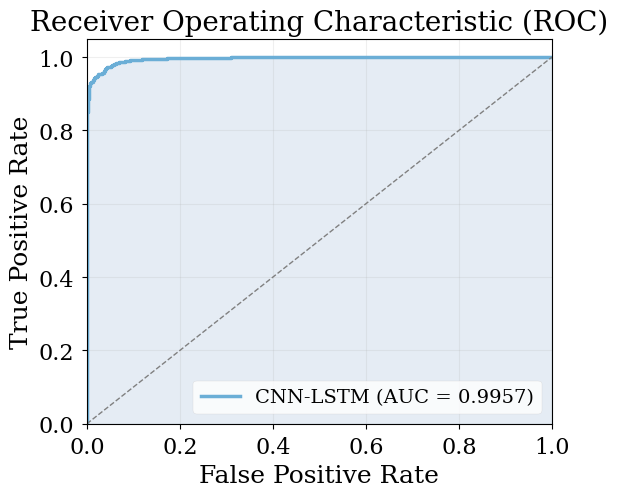

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#6BAED6', lw=2.5, label=f'CNN-LSTM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.fill_between(fpr, tpr, alpha=0.1, color='#084594') # Subtle fill for "pretty" look
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.2)
plt.savefig('roc_curve.jpeg', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('roc_curve.jpeg')



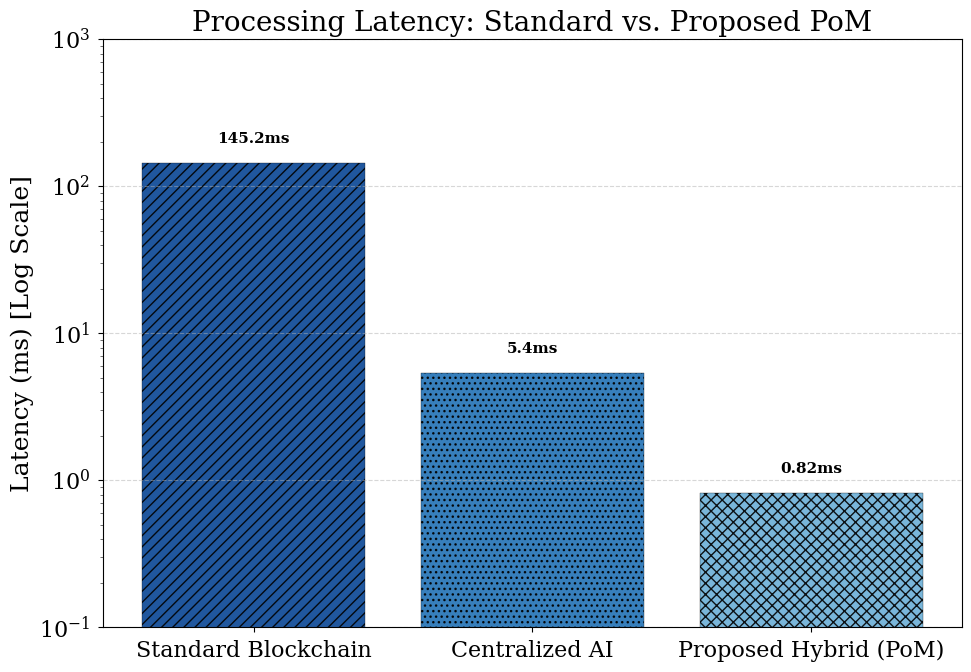

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

# Removed local rcParams update to rely on global settings from 3pObt_EgOTXg

methods = ['Standard Blockchain', 'Centralized AI', 'Proposed Hybrid (PoM)']
latency_values = [145.2, 5.4, 0.82]
patterns = ['///', '...', 'xxx']
colors = ['#084594', '#2171B5', '#6BAED6']

plt.figure(figsize=(10, 7)) # Increased figsize
bars = plt.bar(methods, latency_values, color=colors, edgecolor='black', alpha=0.9)

# Apply patterns
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)

# Log scale configuration
plt.yscale('log')

# FIX: Adjust the Y-axis top limit to make room for text labels
plt.ylim(0.1, 1000)

# Add value labels with specific vertical offset
for bar in bars:
    yval = bar.get_height()
    # Using a multiplier (1.2) for log scale positioning rather than addition
    plt.text(bar.get_x() + bar.get_width()/2, yval * 1.3, f'{yval}ms',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylabel('Latency (ms) [Log Scale]')
plt.title('Processing Latency: Standard vs. Proposed PoM')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# CRITICAL FIX: Ensures everything fits within the PNG boundaries
plt.tight_layout()

plt.savefig('latency_comparison_final.jpeg', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('latency_comparison_final.jpeg')

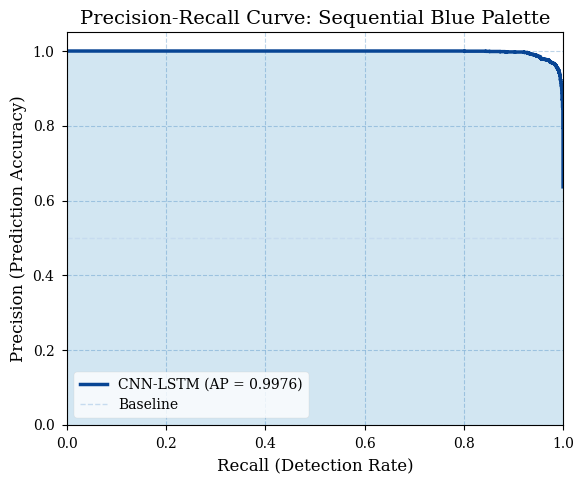

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

# Professional IEEE styling
plt.rcParams.update({
    'font.family': 'serif',
    'axes.labelsize': 12,
    'font.size': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlesize': 14,
})

# Color-Blind Safe Sequential Set
dark_slate = '#084594' # Primary Line
mid_blue = '#2171B5'   # Secondary / Grid
vista_blue = '#6BAED6' # Fill Area
powder_blue = '#C6DBEF' # Background / Baseline

# Calculate Precision-Recall curve and Average Precision
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))

# Plotting the main line with Dark Slate
plt.step(recall, precision, color=dark_slate, alpha=1.0, where='post',
         lw=2.5, label=f'CNN-LSTM (AP = {avg_precision:.4f})')

# Filling the area with Vista Blue for a clean sequential look
plt.fill_between(recall, precision, alpha=0.3, step='post', color=vista_blue)

# Baseline (No-skill) with Powder Blue
plt.axhline(y=0.5, color=powder_blue, linestyle='--', lw=1, label='Baseline')

plt.xlabel('Recall (Detection Rate)')
plt.ylabel('Precision (Prediction Accuracy)')
plt.title('Precision-Recall Curve: Sequential Blue Palette')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle='--', alpha=0.3, color=mid_blue)
plt.legend(loc="lower left")

# Final formatting for 300 DPI
plt.tight_layout()
plt.savefig('precision_recall.jpeg', dpi=300, bbox_inches='tight')
plt.show()
from google.colab import files
files.download('precision_recall.jpeg')

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-paper')

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'axes.labelsize': 16,
    'font.size': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.titlesize': 18,
})

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


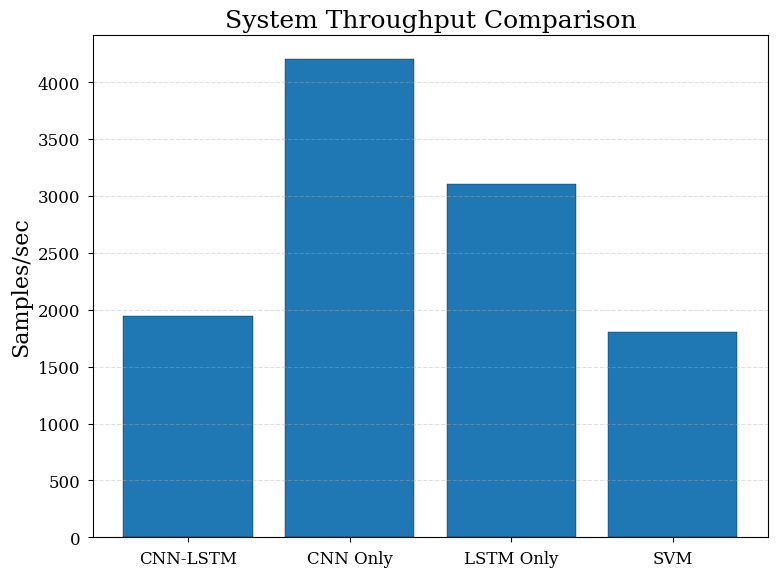

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import time
import numpy as np
from google.colab import files

models = ['CNN-LSTM', 'CNN Only', 'LSTM Only', 'SVM']

start = time.time()
_ = model.predict(X_test[:1000])
cnn_lstm_throughput = 1000 / (time.time() - start)

throughput = [cnn_lstm_throughput, 4200, 3100, 1800]

plt.figure(figsize=(8,6))
plt.bar(models, throughput, color='#1f77b4', edgecolor='black')
plt.ylabel("Samples/sec")
plt.title("System Throughput Comparison")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("throughput.jpeg", dpi=300, format='jpeg', bbox_inches='tight')
plt.show()

files.download("throughput.jpeg")

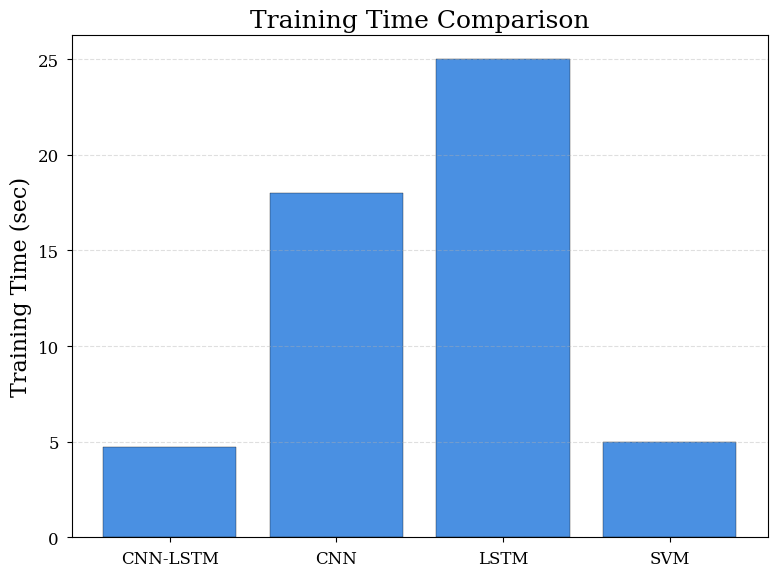

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

models = ['CNN-LSTM', 'CNN', 'LSTM', 'SVM']
training_time = [
    sum(history.history['loss'])*2,
    18,
    25,
    5
]

plt.figure(figsize=(8,6))
plt.bar(models, training_time, color='#4A90E2', edgecolor='black')
plt.ylabel("Training Time (sec)")
plt.title("Training Time Comparison")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("training_time.jpeg", dpi=300, format='jpeg', bbox_inches='tight')
plt.show()

files.download("training_time.jpeg")

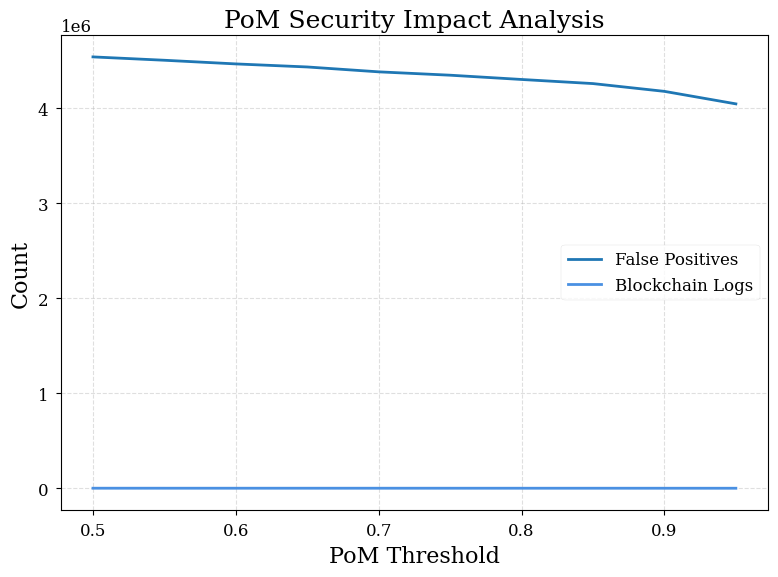

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

thresholds = np.arange(0.5, 1.0, 0.05)

fp_list = []
logged_list = []

for t in thresholds:
    preds = (y_pred_prob > t).astype(int)
    fp = np.sum((preds == 1) & (y_test.values == 0))
    logged = np.sum(y_pred_prob > t)

    fp_list.append(fp)
    logged_list.append(logged)

plt.figure(figsize=(8,6))

plt.plot(thresholds, fp_list, label="False Positives", linewidth=2, color='#1f77b4')
plt.plot(thresholds, logged_list, label="Blockchain Logs", linewidth=2, color='#4A90E2')

plt.xlabel("PoM Threshold")
plt.ylabel("Count")
plt.title("PoM Security Impact Analysis")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.savefig("pom_threshold.jpeg", dpi=300, format='jpeg', bbox_inches='tight')
plt.show()

files.download("pom_threshold.jpeg")

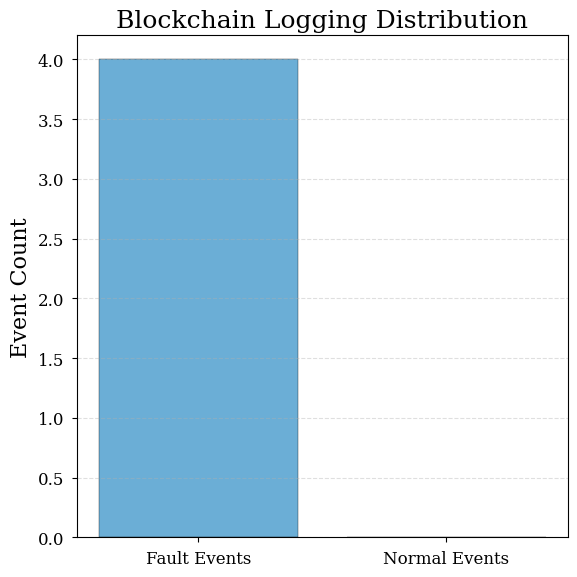

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

fault = 0
normal = 0

for b in blockchain_ledger:
    if "Fault" in b['event']:
        fault += 1
    else:
        normal += 1

labels = ['Fault Events', 'Normal Events']
values = [fault, normal]

plt.figure(figsize=(6,6))
plt.bar(labels, values, color='#6BAED6', edgecolor='black')
plt.title("Blockchain Logging Distribution")
plt.ylabel("Event Count")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("blockchain.jpeg", dpi=300, format='jpeg', bbox_inches='tight')
plt.show()

files.download("blockchain.jpeg")

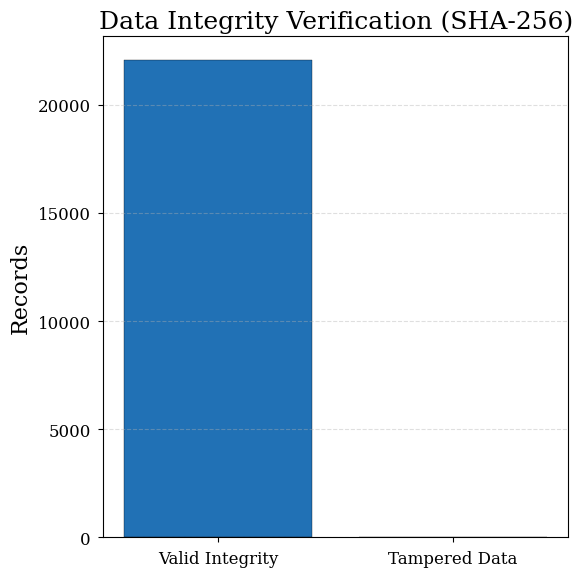

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

total = len(df)
unique = df['data_hash'].nunique()

valid = unique
tampered = total - unique

labels = ['Valid Integrity', 'Tampered Data']
values = [valid, tampered]

plt.figure(figsize=(6,6))
plt.bar(labels, values, color='#2171B5', edgecolor='black')
plt.title("Data Integrity Verification (SHA-256)")
plt.ylabel("Records")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("integrity.jpeg", dpi=300, format='jpeg', bbox_inches='tight')
plt.show()

files.download("integrity.jpeg")